# Importing dependencies

In [78]:
import yfinance as yf  # Used to obtain daily Stock closing prices

In [79]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go   # Used to plot interactive Graphs
import networkx as nx               # Used for making Networks
import community                    # Used for detecting Communities in Network

# Obtaining Stock Data

In [80]:
stocks = pd.read_html('https://ournifty.com/stock-list-in-nse-fo-futures-and-options.html')[0]      # To obtain Tickers
stocks= stocks.drop(['SL NO','LOT SIZE'],axis=1)
stocks = stocks.drop(index=[0,1,2,3,4]).reset_index(drop=True)
stocks

,F&O STOCKS NAME,SYMBOL
0,AARTI INDUSTRIES LTD,AARTIIND
1,ABB INDIA LIMITED,ABB
2,ABBOTT INDIA LIMITED,ABBOTINDIA
3,ADITYA BIRLA CAPITAL LTD.,ABCAPITAL
4,ADITYA BIRLA FASHION & RT,ABFRL
...,...,...
222,WIPRO LTD,WIPRO
223,YES BANK LIMITED,YESBANK
224,ZOMATO LIMITED,ZOMATO
225,ZYDUS LIFESCIENCES LTD,ZYDUSLIFE


Obtaining Tickers of Indian stocks

In [81]:
tickers = stocks.SYMBOL.to_list()
for i in range(len(tickers)):
    tickers[i] = tickers[i] + '.NS'             # .NS is used by yfinance to distinguish the indian stock exchange so we need to add it to ticker symbol to get data
print(len(tickers))
# tickers = tickers[:200]

227


In [82]:
tickers

['AARTIIND.NS',
 'ABB.NS',
 'ABBOTINDIA.NS',
 'ABCAPITAL.NS',
 'ABFRL.NS',
 'ACC.NS',
 'ADANIENSOL.NS',
 'ADANIENT.NS',
 'ADANIGREEN.NS',
 'ADANIPORTS.NS',
 'ALKEM.NS',
 'AMBUJACEM.NS',
 'ANGELONE.NS',
 'APLAPOLLO.NS',
 'APOLLOHOSP.NS',
 'APOLLOTYRE.NS',
 'ASHOKLEY.NS',
 'ASIANPAINT.NS',
 'ASTRAL.NS',
 'ATGL.NS',
 'ATUL.NS',
 'AUBANK.NS',
 'AUROPHARMA.NS',
 'AXISBANK.NS',
 'BAJAJ-AUTO.NS',
 'BAJAJFINSV.NS',
 'BAJFINANCE.NS',
 'BALKRISIND.NS',
 'BANDHANBNK.NS',
 'BANKBARODA.NS',
 'BANKINDIA.NS',
 'BATAINDIA.NS',
 'BEL.NS',
 'BERGEPAINT.NS',
 'BHARATFORG.NS',
 'BHARTIARTL.NS',
 'BHEL.NS',
 'BIOCON.NS',
 'BOSCHLTD.NS',
 'BPCL.NS',
 'BRITANNIA.NS',
 'BSE.NS',
 'BSOFT.NS',
 'CAMS.NS',
 'COALINDIA.NS',
 'DALBHARAT.NS',
 'CANBK.NS',
 'CANFINHOME.NS',
 'CDSL.NS',
 'HINDUNILVR.NS',
 'COFORGE.NS',
 'INDIAMART.NS',
 'INDIANB.NS',
 'IRCTC.NS',
 'JINDALSTEL.NS',
 'CESC.NS',
 'M&MFIN.NS',
 'MARUTI.NS',
 'MGL.NS',
 'NAVINFLUOR.NS',
 'NBCC.NS',
 'NESTLEIND.NS',
 'SBICARD.NS',
 'SHREECEM.NS',
 'SOLARIN

In [83]:
start_date = "2008-01-02"
end_date = '2022-12-31'

In [84]:
my_colums = tickers
date_range = pd.date_range(start=start_date, end=end_date, freq="D")  # Making an empty dataframe
df = pd.DataFrame(columns=my_colums, index=date_range)
df.head()

,AARTIIND.NS,ABB.NS,ABBOTINDIA.NS,ABCAPITAL.NS,ABFRL.NS,ACC.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,...,UNIONBANK.NS,UNITDSPR.NS,VBL.NS,VEDL.NS,VOLTAS.NS,WIPRO.NS,YESBANK.NS,ZOMATO.NS,ZYDUSLIFE.NS,PHOENIXLTD.NS
2008-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Obtaing stock data from yfinance

In [85]:
for ticker in tickers:
    try:
        data = yf.download(ticker, start=start_date, end=end_date)
        data.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
        data = data[['Close']].rename(columns={"Close": ticker})
        df.update(data)

    except Exception as e:
        print(f"Skipping {ticker}: {e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ADANIENSOL.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2008-01-02 -> 2022-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1199212200, endDate = 1672425000")')


Skipping ADANIENSOL.NS: Length mismatch: Expected axis has 6 elements, new values have 5 elements


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Skipping JIOFIN.NS: Length mismatch: Expected axis has 6 elements, new values have 5 elements


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Skipping UNITDSPR.NS: Length mismatch: Expected axis has 6 elements, new values have 5 elements


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


We see there are many stocks with no data available during the starting years , so I drop these stocks

In [86]:
count = df.columns[df.iloc[0].isna()].size
count

80

In [87]:
df = df.loc[:, ~df.iloc[0].isna()]  # Bitmask method for removing columns starting with Nan
df.head()

,AARTIIND.NS,ABB.NS,ABBOTINDIA.NS,ACC.NS,ADANIENT.NS,ADANIPORTS.NS,AMBUJACEM.NS,APOLLOHOSP.NS,APOLLOTYRE.NS,ASHOKLEY.NS,...,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VEDL.NS,VOLTAS.NS,WIPRO.NS,YESBANK.NS,ZYDUSLIFE.NS,PHOENIXLTD.NS
2008-01-02,8.023764,1271.973511,215.615509,756.181763,79.020149,237.939011,107.048264,267.379028,49.024532,16.378956,...,58.933994,28.849203,917.772217,157.806717,57.700966,213.496017,43.966335,47.37891,32.128258,221.153763
2008-01-03,8.467765,1262.673584,215.615509,744.281433,79.360008,232.179123,104.913803,259.326874,47.943115,16.599863,...,56.834335,28.588943,912.456482,156.567108,56.966995,215.232086,42.663712,46.478573,32.148922,218.839127
2008-01-04,8.570835,1270.626709,215.615509,738.885681,79.119949,225.727676,103.719978,259.031982,46.421112,17.041685,...,54.866375,28.408758,903.489197,157.737839,56.825569,215.867264,42.702404,46.36269,31.947382,214.64621
2008-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df.ffill(inplace=True)              # Filling the still present Nan cells with previous day data
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_3644\365474296.py:1: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,AARTIIND.NS,ABB.NS,ABBOTINDIA.NS,ACC.NS,ADANIENT.NS,ADANIPORTS.NS,AMBUJACEM.NS,APOLLOHOSP.NS,APOLLOTYRE.NS,ASHOKLEY.NS,...,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VEDL.NS,VOLTAS.NS,WIPRO.NS,YESBANK.NS,ZYDUSLIFE.NS,PHOENIXLTD.NS
2008-01-02,8.023764,1271.973511,215.615509,756.181763,79.020149,237.939011,107.048264,267.379028,49.024532,16.378956,...,58.933994,28.849203,917.772217,157.806717,57.700966,213.496017,43.966335,47.378910,32.128258,221.153763
2008-01-03,8.467765,1262.673584,215.615509,744.281433,79.360008,232.179123,104.913803,259.326874,47.943115,16.599863,...,56.834335,28.588943,912.456482,156.567108,56.966995,215.232086,42.663712,46.478573,32.148922,218.839127
2008-01-04,8.570835,1270.626709,215.615509,738.885681,79.119949,225.727676,103.719978,259.031982,46.421112,17.041685,...,54.866375,28.408758,903.489197,157.737839,56.825569,215.867264,42.702404,46.362690,31.947382,214.646210
2008-01-05,8.570835,1270.626709,215.615509,738.885681,79.119949,225.727676,103.719978,259.031982,46.421112,17.041685,...,54.866375,28.408758,903.489197,157.737839,56.825569,215.867264,42.702404,46.362690,31.947382,214.646210
2008-01-06,8.570835,1270.626709,215.615509,738.885681,79.119949,225.727676,103.719978,259.031982,46.421112,17.041685,...,54.866375,28.408758,903.489197,157.737839,56.825569,215.867264,42.702404,46.362690,31.947382,214.646210


In [89]:
df =np.log(df / df.shift(1)).fillna(0)   # Obtaining a Log returns Dataframe
df.head()

,AARTIIND.NS,ABB.NS,ABBOTINDIA.NS,ACC.NS,ADANIENT.NS,ADANIPORTS.NS,AMBUJACEM.NS,APOLLOHOSP.NS,APOLLOTYRE.NS,ASHOKLEY.NS,...,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VEDL.NS,VOLTAS.NS,WIPRO.NS,YESBANK.NS,ZYDUSLIFE.NS,PHOENIXLTD.NS
2008-01-02,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2008-01-03,0.053859,-0.007338,0.0,-0.015863,0.004292,-0.024505,-0.020141,-0.030578,-0.022306,0.013397,...,-0.036277,-0.009062,-0.005809,-0.007886,-0.012802,0.008099,-0.030076,-0.019186,0.000643,-0.010521
2008-01-04,0.012099,0.006279,0.0,-0.007276,-0.003030,-0.028180,-0.011444,-0.001138,-0.032261,0.026268,...,-0.035240,-0.006323,-0.009876,0.007450,-0.002486,0.002947,0.000907,-0.002496,-0.006289,-0.019346
2008-01-05,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2008-01-06,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [90]:
years = df.index.year.unique()
years

Index([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022],
      dtype='int32')

In [91]:
df.shape

(5478, 147)

# Helper Functions

In [92]:
def normal_plot(G, timeline, avg_corr,density, ax=None):
    
    '''''
    Funstion used to plot the network, here there are no interactive features in the plot

    '''''

    if  density==0:
        ax.axis('off')
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42, k=0.5)  
    degrees = dict(G.degree()) 

    degree_values = np.array(list(degrees.values()))
    norm = plt.Normalize(degree_values.min(), degree_values.max())  
    node_colors = plt.cm.viridis(norm(degree_values))  

    nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5, ax=ax)

    nodes = nx.draw_networkx_nodes(G, pos, node_size=100, node_color=degree_values, 
                                   edgecolors="black", cmap='viridis', ax=ax)

    plt.colorbar(nodes, label="Node Degree", ax=ax, shrink=0.7)

    ax.set_title(f"Timeline: {timeline} | Avg Correlation: {avg_corr:.3f}| Density: {density:.3f}", fontsize=12)
    ax.axis("off")  
    
    if ax is None:
        plt.show()


In [93]:
def calculate_key_metrics(G,corr_matrix):

    '''''
    Funstion used to calculate key network metrics such as average correlation,density of network, 
    average clustering and top 10 degree central stocks
    
    '''''

    # Calculates Average Correlation
    upper_triangle_values = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    correlation_values = upper_triangle_values.stack().values
    average_corr = np.mean(correlation_values)

    # Calculates Density
    density = nx.density(G)

    # Average Clustering
    avg_clustering = nx.average_clustering(G)  

    # Finding High degree Stocks
    degree_centrality = nx.degree_centrality(G)
    top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    top_degree_stocks = [x for x,y in top_degree]

    return average_corr,avg_clustering,top_degree,density

In [94]:
def timeline_data(year, month):

    '''''
    Funstion used to parse the data, it obtains the given months data and 
    makes 4 devisions allowing us to obtain the data of each week
    
    '''''
    # Dictionary to map month names to numbers
    month_to_number = {
        "Jan": 1, "Feb": 2, "March": 3, "April": 4,
        "May": 5, "June": 6, "July": 7, "Aug": 8,
        "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
    }

    month_number = month_to_number[month]
    monthly_data = df[(df.index.year == year) & (df.index.month == month_number)].copy()  # Use .copy() to avoid fragmentation

    # Define custom week periods
    week_labels = ["Week 1", "Week 2", "Week 3", "Week 4"]
    week_bins = [1, 8, 15, 22, 32]  # Bins for 1-7, 8-14, 15-21, 22-end

    # Assign each date to a custom week
    monthly_data.loc[:, "Week"] = pd.cut(monthly_data.index.day, bins=week_bins, labels=week_labels, right=False)

    # Group by week without aggregation
    weekly_data = {week: group for week, group in monthly_data.groupby("Week", observed=False)}

    return weekly_data


In [95]:
def stock_network(year,month,threshold):   

    '''''
    Funstion used to make a correlation network, we obtain the weekly data find the correlation between stocks, 
    and then an edge is connected between two stocks if their correlation is higher than a threshold
    '''''

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Create subplots with 2 graphs per row
    axes = axes.flatten()
    weekly_data = timeline_data(year,month)

    for i,week in enumerate(weekly_data.keys()):
        G = nx.Graph()

        for stock in df.columns:
            G.add_node(stock)  

        corr_matrix = weekly_data[week].drop(columns=['Week']).corr(method='pearson')
        # Add edges based on correlation threshold
        for stock1 in corr_matrix.columns:
            for stock2 in corr_matrix.columns:
                if stock1 != stock2 and corr_matrix.loc[stock1, stock2] > threshold:
                    G.add_edge(stock1, stock2, weight=corr_matrix.loc[stock1, stock2])
        avg_corr,avg_clustering,top_degree,density = calculate_key_metrics(G,corr_matrix)
        print(f'⭐ {week}')
        print("🔹The Weekly dates are :",weekly_data[week].index.strftime('%Y-%m-%d').tolist())
        print("🔹The average correlation ,density and average clustering of network are:",avg_corr,density,avg_clustering)
        print("🔹The Top 10 Degree Central Stocks of these dates are:",top_degree)
        print('\n')
        normal_plot(G, week, avg_corr,density, axes[i])
    fig.suptitle(f"{year} {month}", fontsize=30)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1, wspace=0.2)  
    plt.show()

# Exogenous Crash (2020)

We devide the Exogenous crash period caused by the pandemic in 2020 into 3 parts: pre-crash (Feb, 2020),crash (March, 2020) and post-crash (April,2020)

In [96]:
year = 2020

In [97]:
threshold = 0.7

⭐ Week 1
🔹The Weekly dates are : ['2020-02-01', '2020-02-02', '2020-02-03', '2020-02-04', '2020-02-05', '2020-02-06', '2020-02-07']
🔹The average correlation ,density and average clustering of network are: 0.22206923500604275 0.2416363805796291 0.6610135091748642
🔹The Top 10 Degree Central Stocks of these dates are: [('M&MFIN.NS', 0.5205479452054794), ('VEDL.NS', 0.5205479452054794), ('GAIL.NS', 0.5), ('JSL.NS', 0.48630136986301364), ('NCC.NS', 0.48630136986301364), ('TATAPOWER.NS', 0.48630136986301364), ('CUMMINSIND.NS', 0.4794520547945205), ('GMRAIRPORT.NS', 0.4794520547945205), ('IOC.NS', 0.4794520547945205), ('SIEMENS.NS', 0.4794520547945205)]


⭐ Week 2
🔹The Weekly dates are : ['2020-02-08', '2020-02-09', '2020-02-10', '2020-02-11', '2020-02-12', '2020-02-13', '2020-02-14']
🔹The average correlation ,density and average clustering of network are: 0.06879769704662908 0.09048550927220203 0.48694866251524943
🔹The Top 10 Degree Central Stocks of these dates are: [('ONGC.NS', 0.205479452

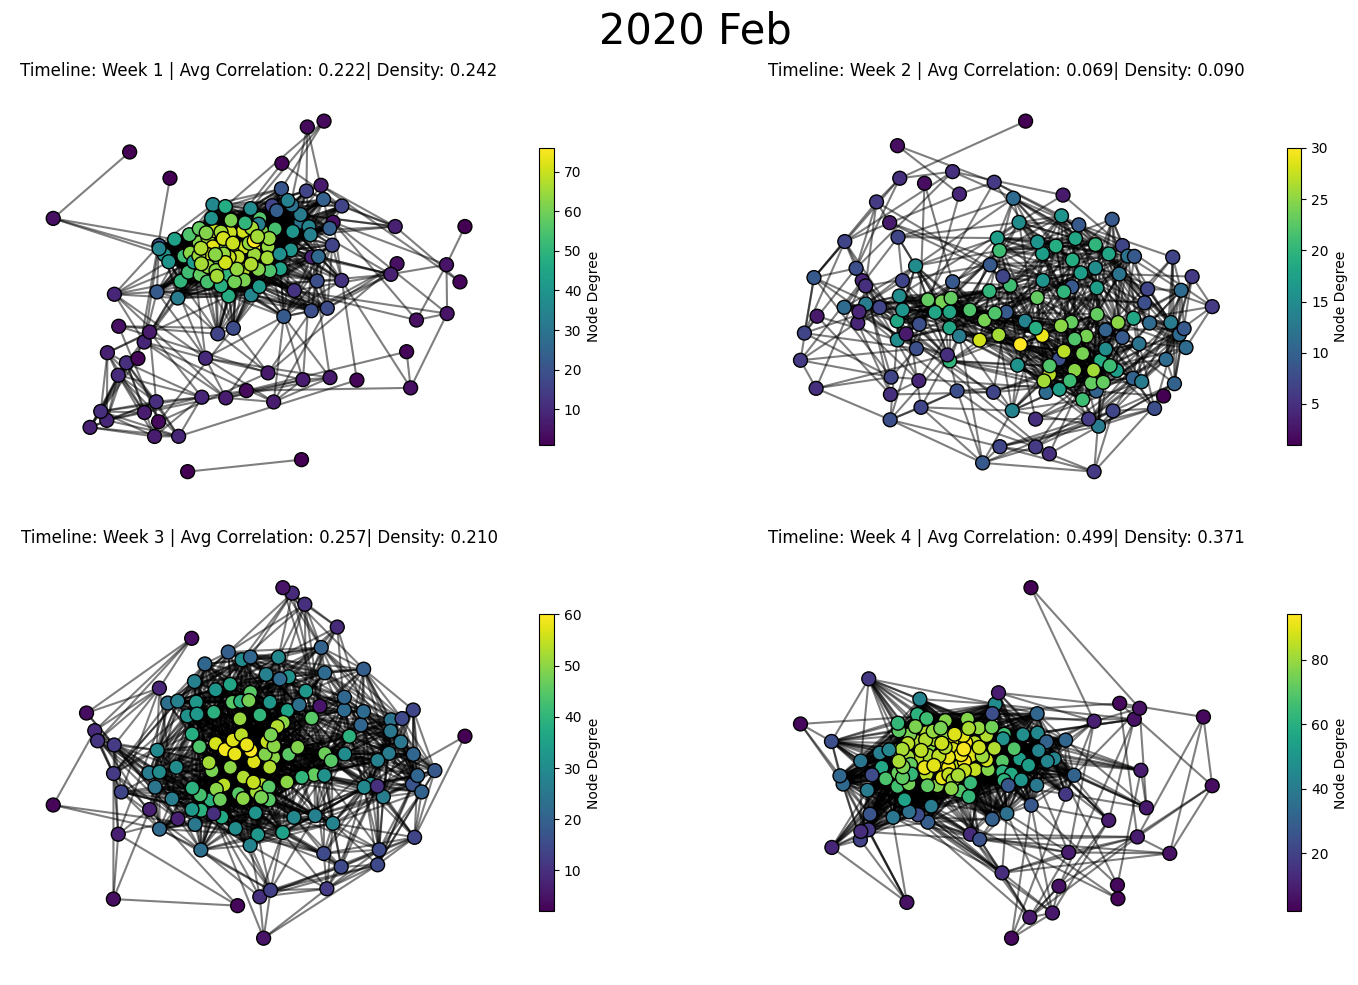

In [98]:
stock_network(year,'Feb',threshold)

⭐ Week 1
🔹The Weekly dates are : ['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04', '2020-03-05', '2020-03-06', '2020-03-07']
🔹The average correlation ,density and average clustering of network are: 0.3504953868731469 0.23557916317211816 0.6148077863954191
🔹The Top 10 Degree Central Stocks of these dates are: [('VEDL.NS', 0.4726027397260274), ('BPCL.NS', 0.45890410958904104), ('JSWSTEEL.NS', 0.45890410958904104), ('MRF.NS', 0.45890410958904104), ('ADANIPORTS.NS', 0.4520547945205479), ('BHEL.NS', 0.4520547945205479), ('NTPC.NS', 0.4520547945205479), ('ONGC.NS', 0.4520547945205479), ('MARICO.NS', 0.4452054794520548), ('TATASTEEL.NS', 0.4452054794520548)]


⭐ Week 2
🔹The Weekly dates are : ['2020-03-08', '2020-03-09', '2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13', '2020-03-14']
🔹The average correlation ,density and average clustering of network are: 0.7624703633107611 0.733109682229056 0.8704291086321693
🔹The Top 10 Degree Central Stocks of these dates are: [('AXISBANK.NS',

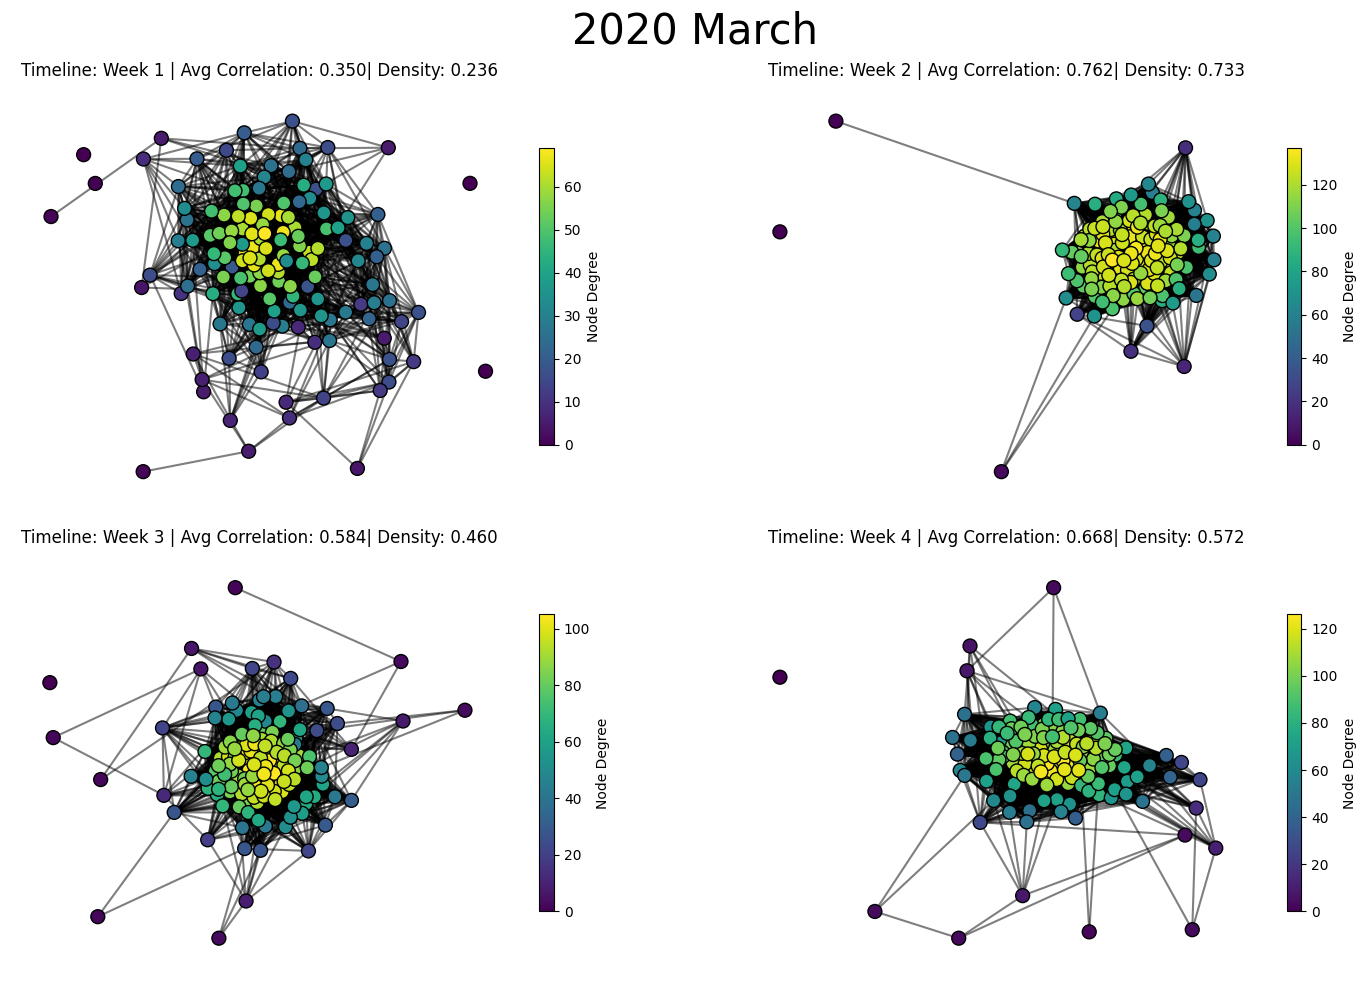

In [99]:
stock_network(year,'March',threshold)

⭐ Week 1
🔹The Weekly dates are : ['2020-04-01', '2020-04-02', '2020-04-03', '2020-04-04', '2020-04-05', '2020-04-06', '2020-04-07']
🔹The average correlation ,density and average clustering of network are: 0.5405455288568516 0.49827602273786226 0.7977423854027469
🔹The Top 10 Degree Central Stocks of these dates are: [('HINDUNILVR.NS', 0.726027397260274), ('INDHOTEL.NS', 0.7191780821917808), ('SIEMENS.NS', 0.7191780821917808), ('ULTRACEMCO.NS', 0.7191780821917808), ('JINDALSTEL.NS', 0.7123287671232876), ('SUNTV.NS', 0.7123287671232876), ('TATACONSUM.NS', 0.7123287671232876), ('CONCOR.NS', 0.7123287671232876), ('DABUR.NS', 0.7123287671232876), ('HCLTECH.NS', 0.7123287671232876)]


⭐ Week 2
🔹The Weekly dates are : ['2020-04-08', '2020-04-09', '2020-04-10', '2020-04-11', '2020-04-12', '2020-04-13', '2020-04-14']
🔹The average correlation ,density and average clustering of network are: 0.31086116425273197 0.2974559686888454 0.6995903075090382
🔹The Top 10 Degree Central Stocks of these dates a

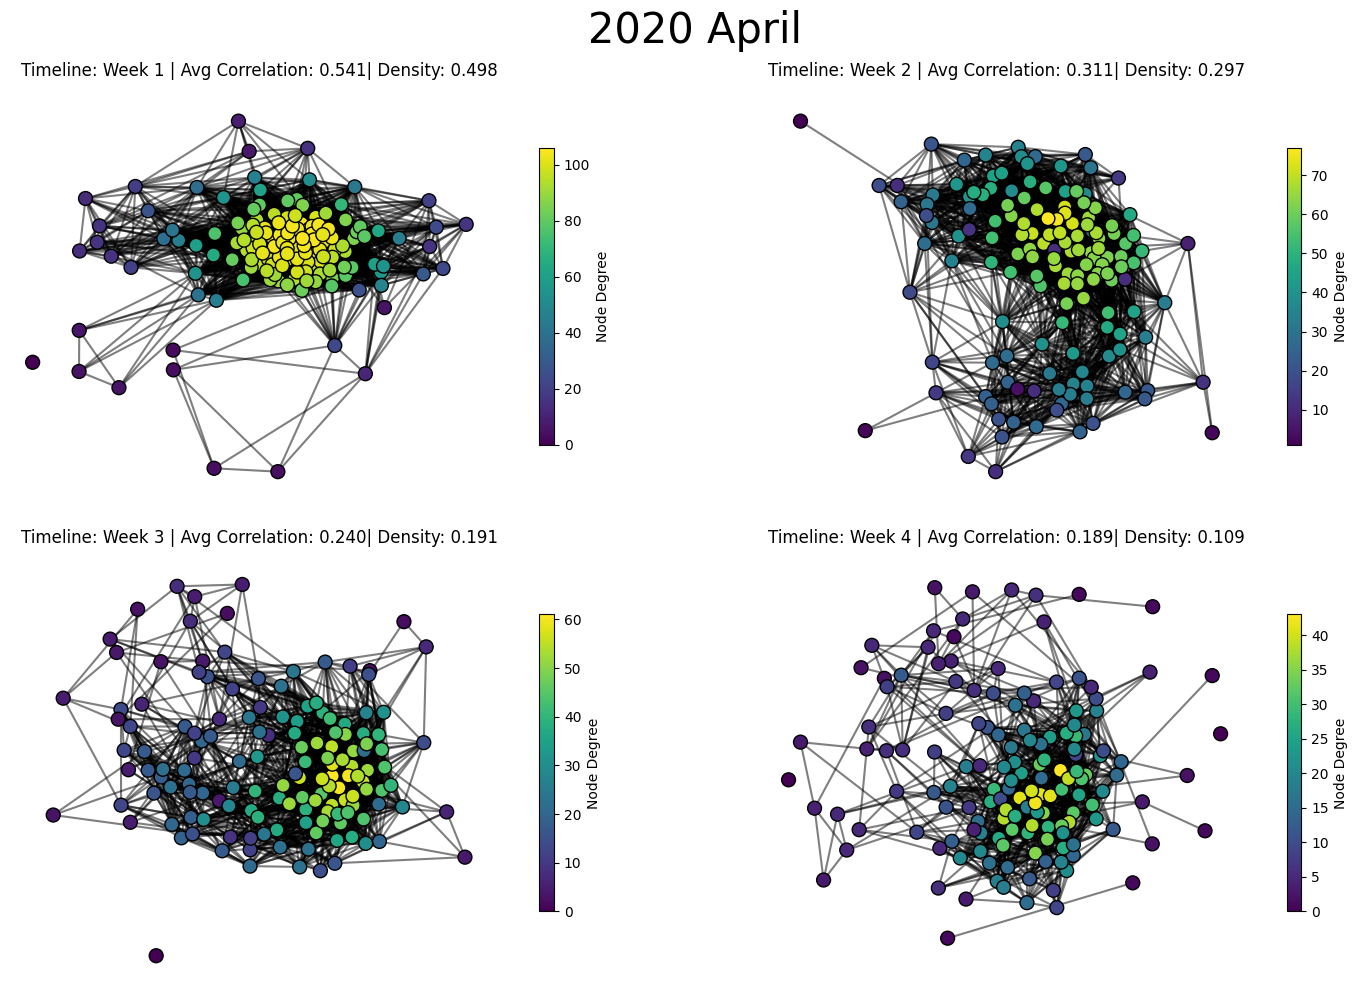

In [100]:
stock_network(year,'April',threshold)

# Indogenous Crash (2008)

We devide the Indogenous crash period caused by the market failure in 2008 into 3 parts: pre-crash (Sep, 2008),crash (Oct, 2008) and post-crash (Nov,2008)

In [101]:
year = 2008

In [102]:
threshold = 0.7

⭐ Week 1
🔹The Weekly dates are : ['2008-09-01', '2008-09-02', '2008-09-03', '2008-09-04', '2008-09-05', '2008-09-06', '2008-09-07']
🔹The average correlation ,density and average clustering of network are: 0.2784341396741146 0.24648215450563787 0.6162242402604088
🔹The Top 10 Degree Central Stocks of these dates are: [('KOTAKBANK.NS', 0.5), ('LT.NS', 0.5), ('DLF.NS', 0.4931506849315068), ('LICHSGFIN.NS', 0.48630136986301364), ('MFSL.NS', 0.4794520547945205), ('ICICIBANK.NS', 0.4726027397260274), ('GRASIM.NS', 0.45890410958904104), ('INFY.NS', 0.4520547945205479), ('POWERGRID.NS', 0.4520547945205479), ('INDUSINDBK.NS', 0.4452054794520548)]


⭐ Week 2
🔹The Weekly dates are : ['2008-09-08', '2008-09-09', '2008-09-10', '2008-09-11', '2008-09-12', '2008-09-13', '2008-09-14']
🔹The average correlation ,density and average clustering of network are: 0.2863847234768631 0.1985835430062436 0.5844077873642344
🔹The Top 10 Degree Central Stocks of these dates are: [('PFC.NS', 0.4383561643835616), ('AM

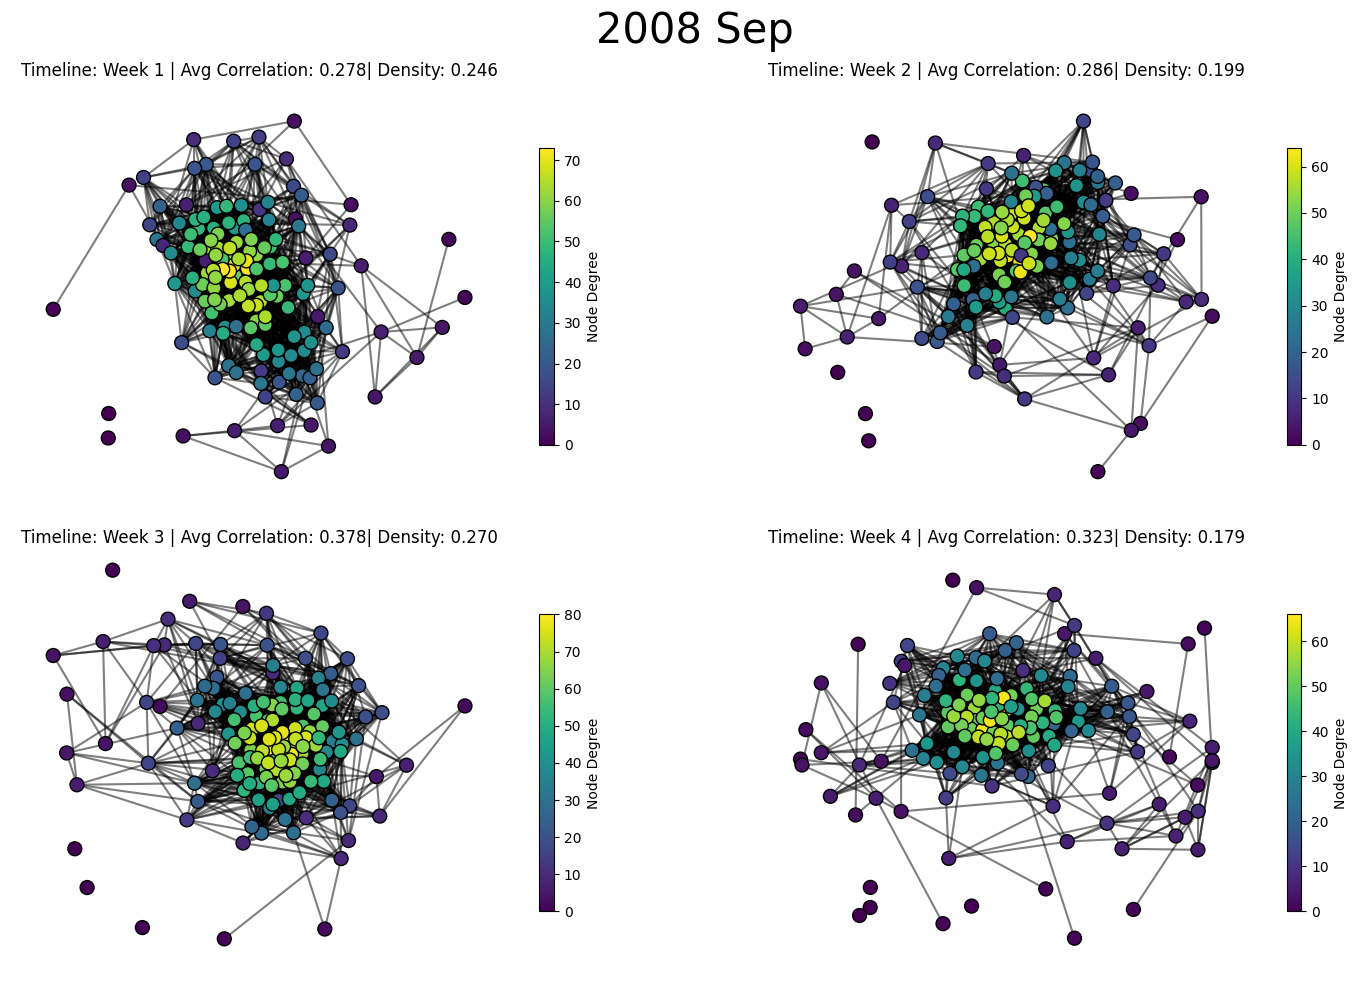

In [103]:
stock_network(year,'Sep',threshold)

⭐ Week 1
🔹The Weekly dates are : ['2008-10-01', '2008-10-02', '2008-10-03', '2008-10-04', '2008-10-05', '2008-10-06', '2008-10-07']
🔹The average correlation ,density and average clustering of network are: 0.4749099895961782 0.34302488118535085 0.673771753923748
🔹The Top 10 Degree Central Stocks of these dates are: [('TATACHEM.NS', 0.6095890410958904), ('BOSCHLTD.NS', 0.6027397260273972), ('ESCORTS.NS', 0.6027397260273972), ('TORNTPHARM.NS', 0.595890410958904), ('HFCL.NS', 0.5821917808219178), ('TATAPOWER.NS', 0.5821917808219178), ('YESBANK.NS', 0.5821917808219178), ('CHAMBLFERT.NS', 0.5753424657534246), ('ATUL.NS', 0.5616438356164384), ('SRF.NS', 0.5616438356164384)]


⭐ Week 2
🔹The Weekly dates are : ['2008-10-08', '2008-10-09', '2008-10-10', '2008-10-11', '2008-10-12', '2008-10-13', '2008-10-14']
🔹The average correlation ,density and average clustering of network are: 0.566822876773717 0.4700400708228497 0.7678238543140061
🔹The Top 10 Degree Central Stocks of these dates are: [('OFSS

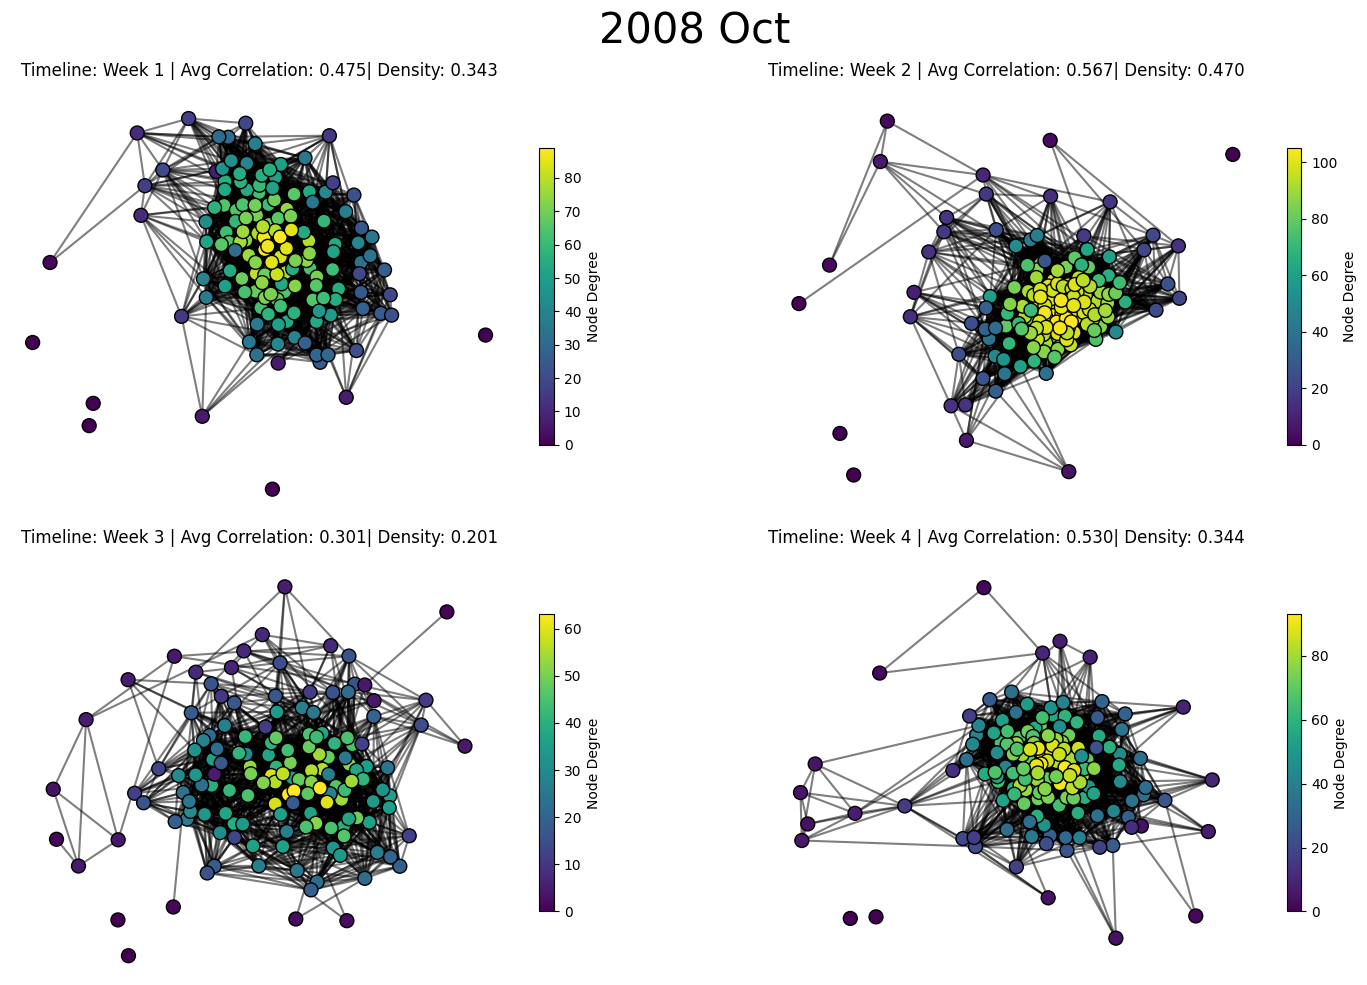

In [104]:
stock_network(year,'Oct',threshold)

⭐ Week 1
🔹The Weekly dates are : ['2008-11-01', '2008-11-02', '2008-11-03', '2008-11-04', '2008-11-05', '2008-11-06', '2008-11-07']
🔹The average correlation ,density and average clustering of network are: 0.3156699452252301 0.24750722206690895 0.6543462887054353
🔹The Top 10 Degree Central Stocks of these dates are: [('CHOLAFIN.NS', 0.5410958904109588), ('MARICO.NS', 0.5273972602739726), ('AXISBANK.NS', 0.5205479452054794), ('YESBANK.NS', 0.5068493150684932), ('CGPOWER.NS', 0.5), ('SBIN.NS', 0.5), ('HDFCBANK.NS', 0.4931506849315068), ('PFC.NS', 0.4931506849315068), ('TORNTPHARM.NS', 0.4931506849315068), ('CHAMBLFERT.NS', 0.48630136986301364)]


⭐ Week 2
🔹The Weekly dates are : ['2008-11-08', '2008-11-09', '2008-11-10', '2008-11-11', '2008-11-12', '2008-11-13', '2008-11-14']
🔹The average correlation ,density and average clustering of network are: 0.43013066288334595 0.36511042773273694 0.7352762666855249
🔹The Top 10 Degree Central Stocks of these dates are: [('JSL.NS', 0.6232876712328766

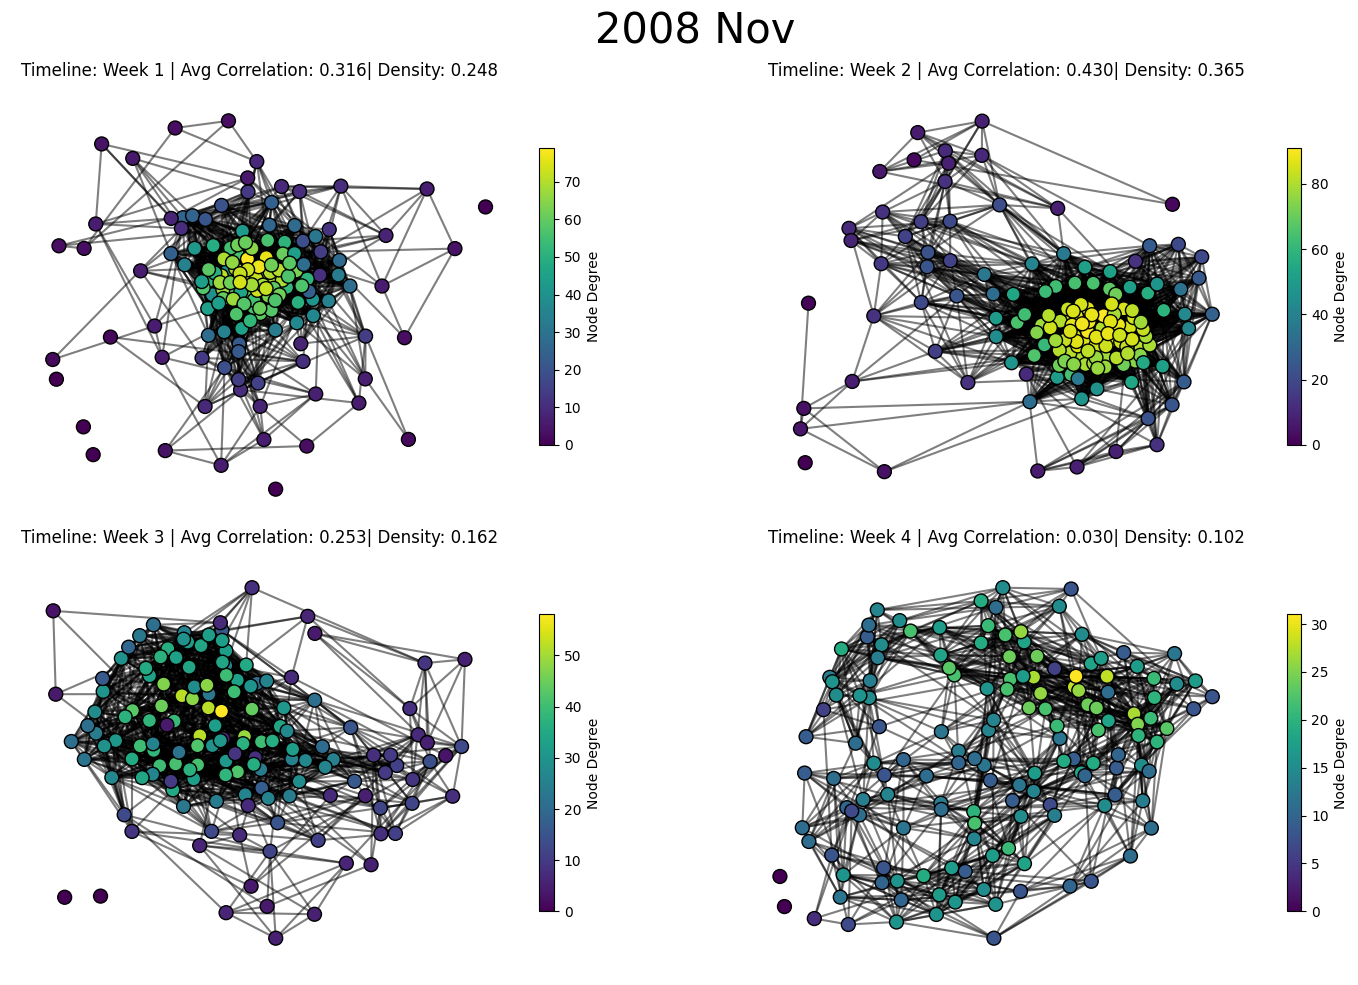

In [105]:
stock_network(year,'Nov',threshold)

# Interactive Plot of Network

In [106]:
def interactive_plot(G, timeline, avg_corr,density):
    
    # Get node positions using spring layout
    pos = nx.spring_layout(G)

    # Compute node degrees
    degrees = dict(G.degree())  # Dictionary {node: degree}
    degree_values = np.array(list(degrees.values()))  # Convert to numpy array for scaling

    # Normalize degree values for color mapping (0 to 1 scale)
    norm_degrees = (degree_values - degree_values.min()) / (degree_values.max() - degree_values.min())

    # Extract edge positions for plotting
    edge_x, edge_y = [], []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])  # None creates line breaks
        edge_y.extend([y0, y1, None])

    # Create edges trace
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='gray'),
        mode='lines',
        hoverinfo='none'
    )

    # Extract node positions
    node_x = [pos[node][0] for node in G.nodes()]
    node_y = [pos[node][1] for node in G.nodes()]

    # Create nodes trace with color mapping based on degrees
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(
            size=10,
            color=norm_degrees,  # Use normalized degree values for color
            colorscale='Viridis',  # Choose a color scale (options: 'Plasma', 'Cividis', 'Inferno')
            showscale=True,  # Show color scale legend
            colorbar=dict(title="Node Degree")  # Label the color scale
        ),
        text=[f"Node {node}<br>Degree: {degrees[node]}" for node in G.nodes()],  # Display degree on hover
        hoverinfo='text'
    )

    # Create interactive plot
    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        showlegend=False,
        hovermode='closest',
        title=f"Indian Stock Market Correlation Network (Color Graded by Degree)<br>Timeline: {timeline} | Avg Corr: {avg_corr:.3f} | Density: {density:.3f}",
        width=1000,
        height=700,
        xaxis=dict(showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False, zeroline=False),
        annotations=[
            dict(
                x=0.5, y=-0.1, xref="paper", yref="paper",
                text=f"Average Correlation Coefficient: {avg_corr:.3f}",
                showarrow=False,
                font=dict(size=14)
            )
        ]
    )

    fig.show()


In [112]:
weekly_data = timeline_data(2020,'March')
data = weekly_data['Week 2'].drop(columns=['Week'])
corr_matrix_tot = data.corr()
print(corr_matrix_tot)

               AARTIIND.NS    ABB.NS  ABBOTINDIA.NS    ACC.NS  ADANIENT.NS  \
AARTIIND.NS       1.000000  0.751369       0.865735  0.952061     0.725108   
ABB.NS            0.751369  1.000000       0.423879  0.672167     0.920381   
ABBOTINDIA.NS     0.865735  0.423879       1.000000  0.944331     0.292246   
ACC.NS            0.952061  0.672167       0.944331  1.000000     0.556342   
ADANIENT.NS       0.725108  0.920381       0.292246  0.556342     1.000000   
...                    ...       ...            ...       ...          ...   
VOLTAS.NS         0.814645  0.424065       0.980533  0.907308     0.234659   
WIPRO.NS          0.916400  0.941231       0.632419  0.814649     0.909463   
YESBANK.NS        0.151422 -0.021198      -0.133576 -0.128477     0.332774   
ZYDUSLIFE.NS      0.968505  0.592885       0.920627  0.926013     0.566623   
PHOENIXLTD.NS     0.810085  0.879073       0.429807  0.619574     0.948331   

               ADANIPORTS.NS  AMBUJACEM.NS  APOLLOHOSP.NS  APOL

In [114]:
weekly_data = timeline_data(2020,'March')
data = weekly_data['Week 2'].drop(columns=['Week'])
data = data.drop('JSL.NS', axis=1)
corr_matrix_tot = data.corr()
print(corr_matrix_tot)

               AARTIIND.NS    ABB.NS  ABBOTINDIA.NS    ACC.NS  ADANIENT.NS  \
AARTIIND.NS       1.000000  0.751369       0.865735  0.952061     0.725108   
ABB.NS            0.751369  1.000000       0.423879  0.672167     0.920381   
ABBOTINDIA.NS     0.865735  0.423879       1.000000  0.944331     0.292246   
ACC.NS            0.952061  0.672167       0.944331  1.000000     0.556342   
ADANIENT.NS       0.725108  0.920381       0.292246  0.556342     1.000000   
...                    ...       ...            ...       ...          ...   
VOLTAS.NS         0.814645  0.424065       0.980533  0.907308     0.234659   
WIPRO.NS          0.916400  0.941231       0.632419  0.814649     0.909463   
YESBANK.NS        0.151422 -0.021198      -0.133576 -0.128477     0.332774   
ZYDUSLIFE.NS      0.968505  0.592885       0.920627  0.926013     0.566623   
PHOENIXLTD.NS     0.810085  0.879073       0.429807  0.619574     0.948331   

               ADANIPORTS.NS  AMBUJACEM.NS  APOLLOHOSP.NS  APOL

In [115]:

G = nx.Graph()

for stock in data.columns:
    G.add_node(stock)   

for stock1 in corr_matrix_tot.columns:
    for stock2 in corr_matrix_tot.columns:
        if stock1 != stock2 and corr_matrix_tot.loc[stock1, stock2] > threshold:
            G.add_edge(stock1, stock2, weight=corr_matrix_tot.loc[stock1, stock2])


upper_triangle_values = corr_matrix_tot.where(np.triu(np.ones(corr_matrix_tot.shape), k=1).astype(bool))
correlation_values = upper_triangle_values.stack().values
avg_corr = np.mean(correlation_values)
density = nx.density(G)
interactive_plot(G, '2015-2022', avg_corr,density)

In [116]:
# 1️⃣ Basic Info
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
average_degree = np.mean([deg for _, deg in G.degree()])

# 2️⃣ Centrality Measures
degree_centrality = nx.degree_centrality(G)  # Connectivity importance
betweenness_centrality = nx.betweenness_centrality(G)  # Bridging nodes
closeness_centrality = nx.closeness_centrality(G)  # Influence based on reachability

# Find top 5 important nodes based on centrality
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

# 3️⃣ Connectivity & Structure
num_components = nx.number_connected_components(G)
largest_component = max(nx.connected_components(G), key=len)
diameter = nx.diameter(G.subgraph(largest_component)) if num_components == 1 else "Graph is not fully connected"
avg_clustering = nx.average_clustering(G)  # Measures local density
avg_shortest_path = nx.average_shortest_path_length(G.subgraph(largest_component)) if num_components == 1 else "N/A"


# Print results
print(f"🔹 Number of Nodes: {num_nodes}")
print(f"🔹 Number of Edges: {num_edges}")
print(f"🔹 Average Degree: {average_degree:.2f}")
print(f"🔹 Connected Components: {num_components}")
print(f"🔹 Largest Component Size: {len(largest_component)}")
print(f"🔹 Diameter: {diameter}")
print(f"🔹 Average Clustering Coefficient: {avg_clustering:.4f}")
print(f"🔹 Average Shortest Path Length: {avg_shortest_path}")
print("\n🔹 Top 5 Nodes by Degree Centrality:", top_degree)
print("🔹 Top 5 Nodes by Betweenness Centrality:", top_betweenness)
print("🔹 Top 5 Nodes by Closeness Centrality:", top_closeness)


🔹 Number of Nodes: 146
🔹 Number of Edges: 7742
🔹 Average Degree: 106.05
🔹 Connected Components: 2
🔹 Largest Component Size: 145
🔹 Diameter: Graph is not fully connected
🔹 Average Clustering Coefficient: 0.8695
🔹 Average Shortest Path Length: N/A

🔹 Top 5 Nodes by Degree Centrality: [('AXISBANK.NS', 0.9379310344827586), ('SIEMENS.NS', 0.9379310344827586), ('AARTIIND.NS', 0.9241379310344827), ('BAJAJFINSV.NS', 0.9241379310344827), ('OFSS.NS', 0.9241379310344827)]
🔹 Top 5 Nodes by Betweenness Centrality: [('CHAMBLFERT.NS', 0.014082470481341529), ('EICHERMOT.NS', 0.006818252010325171), ('KEI.NS', 0.004913882641565988), ('SUPREMEIND.NS', 0.004163867108242349), ('GODREJCP.NS', 0.004038325314351763)]
🔹 Top 5 Nodes by Closeness Centrality: [('AXISBANK.NS', 0.9408348457350272), ('SIEMENS.NS', 0.9408348457350272), ('AARTIIND.NS', 0.9286162113748321), ('BAJAJFINSV.NS', 0.9286162113748321), ('OFSS.NS', 0.9226251390433816)]


In [117]:
# Apply Louvain community detection
partition = community.best_partition(G)

# Count nodes in each community
community_sizes = {}
for node, comm in partition.items():
    community_sizes[comm] = community_sizes.get(comm, 0) + 1

# Filter communities with more than 3 nodes
filtered_communities = {comm for comm, size in community_sizes.items() if size > 2}

# Assign colors: Unique for filtered communities, gray for others
unique_communities = set(partition.values())
colors = {
    comm: f"rgb({np.random.randint(0,255)}, {np.random.randint(0,255)}, {np.random.randint(0,255)})"
    if comm in filtered_communities else "gray"
    for comm in unique_communities
}

# Node positions
pos = nx.spring_layout(G)

# Create edges
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1, color="lightgray"),
    hoverinfo="none",
    mode="lines"
)

# Create separate traces for filtered and random communities
node_traces = []
random_x, random_y, random_text = [], [], []  # To store nodes in small communities

for comm in unique_communities:
    node_x, node_y, node_text = [], [], []
    for node in G.nodes():
        if partition[node] == comm:
            x, y = pos[node]
            if comm in filtered_communities:
                node_x.append(x)
                node_y.append(y)
                node_text.append(f"Node {node} - Community {comm}")
            else:
                random_x.append(x)
                random_y.append(y)
                random_text.append(f"Node {node} - Rest")

    # Plot only filtered communities separately
    if comm in filtered_communities:
        node_trace = go.Scatter(
            x=node_x, y=node_y,
            mode="markers",
            marker=dict(size=10, color=colors[comm], line=dict(width=1, color="black")),
            text=node_text,
            hoverinfo="text",
            name=f"Community {comm}"  # Each filtered community has a separate legend entry
        )
        node_traces.append(node_trace)

# Add a single trace for all "Random" nodes
if random_x:
    random_trace = go.Scatter(
        x=random_x, y=random_y,
        mode="markers",
        marker=dict(size=10, color="gray", line=dict(width=1, color="black")),
        text=random_text,
        hoverinfo="text",
        name="Rest"  # All small communities are grouped in one legend entry
    )
    node_traces.append(random_trace)

# Create the final figure
fig = go.Figure()
fig.add_trace(edge_trace)  # Add edges
for trace in node_traces:
    fig.add_trace(trace)  # Add nodes

fig.update_layout(
    title="Indian Stock Market Network Graph with Community(>2) Colors",
    showlegend=True,
    hovermode="closest",
    width=1000,
    height=700,
    margin=dict(b=0, l=0, r=0, t=40),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
)

fig.show()


In [71]:
filtered_nodes = {node for node, comm in partition.items() if comm in filtered_communities}

# Create a subgraph with only the filtered communities
G_filtered = G.subgraph(filtered_nodes)
# Print the filtered communities
for comm in filtered_communities:
    members = [node for node in partition if partition[node] == comm]
    print(f"Community {comm}: {members} (Size: {len(members)})")

Community 0: ['AARTIIND.NS', 'ABB.NS', 'BANKINDIA.NS', 'CANBK.NS', 'INDIANB.NS', 'GRASIM.NS', 'COLPAL.NS', 'DLF.NS', 'FEDERALBNK.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'JSWSTEEL.NS', 'NATIONALUM.NS', 'NCC.NS', 'PNB.NS', 'NTPC.NS', 'ONGC.NS', 'PEL.NS', 'RAMCOCEM.NS', 'SAIL.NS', 'SUNPHARMA.NS', 'SRF.NS', 'TATACOMM.NS', 'TATAMOTORS.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'UNIONBANK.NS', 'VEDL.NS'] (Size: 28)
Community 2: ['ADANIPORTS.NS', 'ASIANPAINT.NS', 'AUROPHARMA.NS', 'BAJAJFINSV.NS', 'BAJFINANCE.NS', 'BIOCON.NS', 'COFORGE.NS', 'SUNTV.NS', 'UPL.NS', 'CYIENT.NS', 'ESCORTS.NS', 'GLENMARK.NS', 'LICHSGFIN.NS', 'GODREJCP.NS', 'INDHOTEL.NS', 'KEI.NS', 'PETRONET.NS', 'TECHM.NS', 'TORNTPHARM.NS', 'YESBANK.NS', 'PHOENIXLTD.NS'] (Size: 21)
Community 3: ['ADANIENT.NS', 'APOLLOHOSP.NS', 'ASTRAL.NS', 'ATUL.NS', 'BEL.NS', 'BERGEPAINT.NS', 'BHARATFORG.NS', 'BHEL.NS', 'BSOFT.NS', 'SOLARINDS.NS', 'CONCOR.NS', 'INDUSINDBK.NS', 'GRANULES.NS', 'COROMANDEL.NS', 'CUB.NS', 'CUMMINSIND.NS', 'JKCEMENT.NS', 'JSL.NS', '